<a href="https://colab.research.google.com/github/JoGabTasca/NLP/blob/main/classificacao_discurso_odio_olid_br.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Discurso de Ódio — OLID-BR

Neste notebook, vamos treinar um modelo de **detecção de discurso de ódio** utilizando o dataset [OLID-BR](https://huggingface.co/datasets/dougtrajano/olid-br) e comparar as técnicas clássicas de feature extraction: **Bag of Words** e **TF-IDF**.

### ⚠️ Atenção: Complexidade da Tarefa

A detecção de discurso de ódio é uma das tarefas mais desafiadoras em NLP. Isso porque:

- A linha entre **crítica ácida**, **ofensa comum** e **discurso de ódio** direcionado a grupos protegidos é **muito tênue**.
- O uso de **gírias**, **eufemismos** e **linguagem codificada** (*dog-whistles*) dificulta a identificação automática.
- O dataset contém **muitos casos ambíguos** que exigem julgamento de contexto.

### Sobre o Dataset

O **OLID-BR** (Offensive Language Identification Dataset for Brazilian Portuguese) contém comentários em português coletados de redes sociais, anotados como ofensivos (`OFF`) ou não ofensivos (`NOT`). É especificamente projetado para o português brasileiro, com suas particularidades linguísticas.

### Descrição dos Campos do Dataset OLID-BR

Este dataset contém os seguintes campos:

- **`id`** (string): Identificador único da instância.
- **`text`** (string): O texto da instância a ser classificado.
- **`is_offensive`** (string): Indica se o texto é ofensivo (`OFF`) ou não (`NOT`).
- **`is_targeted`** (string): Indica se a ofensa é direcionada (`TIN` - Targeted) ou não (`UNT` - Untargeted).
- **`targeted_type`** (string): Tipo do alvo, se `is_targeted` for verdadeiro. Pode ser `IND` (Indivíduo), `GRP` (Grupo) ou `OTH` (Outro).
- **`toxic_spans`** (string): Lista de trechos tóxicos dentro do texto.
- **`health`** (boolean): Indica se o texto contém discurso de ódio baseado em condições de saúde (ex: deficiência, doença).
- **`ideology`** (boolean): Indica se o texto contém discurso de ódio baseado nas ideias ou crenças de uma pessoa.
- **`insult`** (boolean): Indica se o texto contém insulto, conteúdo inflamatório ou provocativo.
- **`lgbtqphobia`** (boolean): Indica se o texto contém conteúdo prejudicial relacionado à identidade de gênero ou orientação sexual (LGBTQIA+phobia).
- **`other_lifestyle`** (boolean): Indica se o texto contém discurso de ódio relacionado a hábitos de vida (ex: veganismo, vegetarianismo).
- **`physical_aspects`** (boolean): Indica se o texto contém discurso de ódio relacionado à aparência física.
- **`profanity_obscene`** (boolean): Indica se o texto contém palavrões ou conteúdo obsceno.
- **`racism`** (boolean): Indica se o texto contém pensamentos preconceituosos ou ações discriminatórias baseadas em diferenças de raça/etnia.
- **`religious_intolerance`** (boolean): Indica se o texto contém intolerância religiosa.
- **`sexism`** (boolean): Indica se o texto contém conteúdo discriminatório baseado em diferenças de sexo/gênero (ex: sexismo, misoginia).
- **`xenophobia`** (boolean): Indica se o texto contém discurso de ódio contra estrangeiros.

## 1. Instalação e Importação de Bibliotecas

In [ ]:
# Instalando dependências necessárias
!pip install datasets spacy --quiet
!python -m spacy download pt_core_news_sm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 23.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    ConfusionMatrixDisplay, classification_report
)

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento do Dataset

In [ ]:
splits = {
    'train': 'data/train-00000-of-00001-0d8933b80051ca0e.parquet',
    'test':  'data/test-00000-of-00001-914dbee7561d2266.parquet'
}

df_train = pd.read_parquet("hf://datasets/dougtrajano/olid-br/" + splits["train"])
df_test  = pd.read_parquet("hf://datasets/dougtrajano/olid-br/" + splits["test"])

print(f"Treino: {df_train.shape}")
print(f"Teste:  {df_test.shape}")
df_train.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Treino: (5214, 17)
Teste:  (1738, 17)


,id,text,is_offensive,is_targeted,targeted_type,toxic_spans,health,ideology,insult,lgbtqphobia,other_lifestyle,physical_aspects,profanity_obscene,racism,religious_intolerance,sexism,xenophobia
0,c779826dc43f460cb18e8429ca443477,Pior do que adolescentezinhas de merda...são p...,OFF,UNT,None,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",False,False,True,False,False,False,True,False,False,True,False
1,a3d7839456ae4258a70298fcf637952e,"Podia ter beijo também, pra ver se o homofóbic...",OFF,UNT,None,"[24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 3...",False,False,True,False,False,False,False,False,False,False,False
2,b830374760cc44789f1493c6b228ebc1,"o monark não é racista que filha da putagem, j...",OFF,TIN,GRP,"[36, 37, 38, 39, 40, 41, 42]",False,False,True,False,False,False,False,False,False,False,False
3,73299805588d424fa2905eaf9e616cf1,fudeu minha mãe acabou de chegar em casa e eu ...,OFF,TIN,OTH,"[0, 1, 2, 3, 4, 5, 72, 73, 74]",False,False,True,False,False,False,True,False,False,False,False
4,862cf8f819814e47bb4e7f6b4b0afc73,"Vergonha,ainda segura a bandeira de um país de...",OFF,UNT,None,"[58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 6...",False,True,True,True,False,False,False,False,False,False,True


In [ ]:
# Verificando colunas disponíveis
print("Colunas:", df_train.columns.tolist())
df_train.info()

Colunas: ['id', 'text', 'is_offensive', 'is_targeted', 'targeted_type', 'toxic_spans', 'health', 'ideology', 'insult', 'lgbtqphobia', 'other_lifestyle', 'physical_aspects', 'profanity_obscene', 'racism', 'religious_intolerance', 'sexism', 'xenophobia']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5214 entries, 0 to 5213
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     5214 non-null   object
 1   text                   5214 non-null   object
 2   is_offensive           5214 non-null   object
 3   is_targeted            5214 non-null   object
 4   targeted_type          2987 non-null   object
 5   toxic_spans            4746 non-null   object
 6   health                 5214 non-null   bool  
 7   ideology               5214 non-null   bool  
 8   insult                 5214 non-null   bool  
 9   lgbtqphobia            5214 non-null   bool  
 10  other_lifestyle        

## 3. Exploração dos Dados (EDA)

In [ ]:
# Distribuição do rótulo alvo (subtask_a: OFF = ofensivo, NOT = não ofensivo)
print("Distribuição de classes (treino):")
print(df_train['is_offensive'].value_counts())
print()
print("Distribuição de classes (teste):")
print(df_test['is_offensive'].value_counts())

Distribuição de classes (treino):
is_offensive
OFF    4452
NOT     762
Name: count, dtype: int64

Distribuição de classes (teste):
is_offensive
OFF    1484
NOT     254
Name: count, dtype: int64


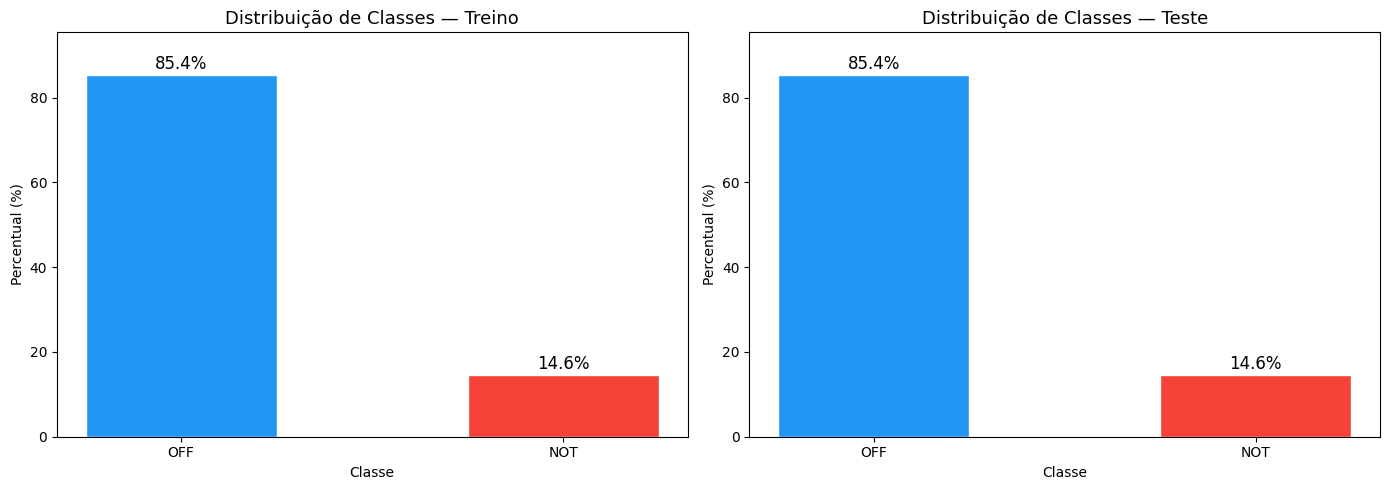

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, titulo in zip(axes, [df_train, df_test], ['Treino', 'Teste']):
    counts = df['is_offensive'].value_counts()
    percentages = df['is_offensive'].value_counts(normalize=True) * 100
    bars = ax.bar(counts.index, percentages.values,
                  color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
    for bar, pct in zip(bars, percentages.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=12)
    ax.set_title(f'Distribuição de Classes — {titulo}', fontsize=13)
    ax.set_xlabel('Classe')
    ax.set_ylabel('Percentual (%)')
    ax.set_ylim(0, max(percentages.values) + 10)

plt.tight_layout()
plt.show()

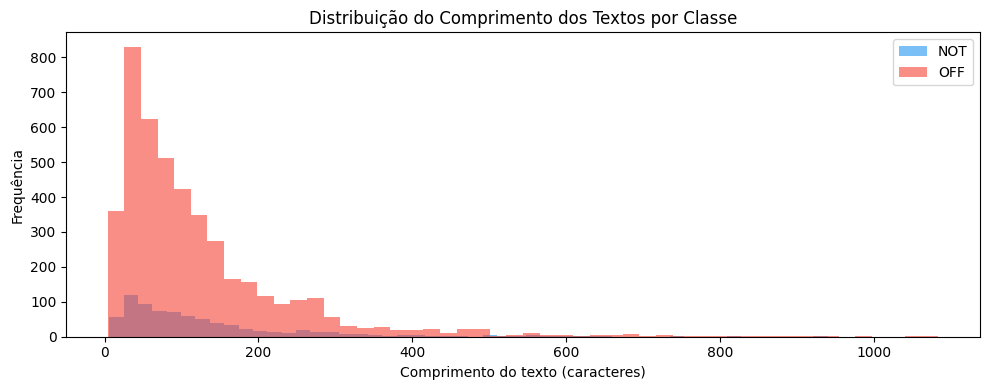

               count        mean         std  min   25%   50%    75%     max
is_offensive                                                                
NOT            762.0  126.568241  120.062648  6.0  46.0  89.5  162.0   940.0
OFF           4452.0  122.494609  119.493525  4.0  46.0  86.0  153.0  1084.0


In [ ]:
# Comprimento dos textos
df_train['text_len'] = df_train['text'].str.len()

plt.figure(figsize=(10, 4))
for label, color in zip(['NOT', 'OFF'], ['#2196F3', '#F44336']):
    subset = df_train[df_train['is_offensive'] == label]['text_len']
    plt.hist(subset, bins=50, alpha=0.6, label=label, color=color)
plt.xlabel('Comprimento do texto (caracteres)')
plt.ylabel('Frequência')
plt.title('Distribuição do Comprimento dos Textos por Classe')
plt.legend()
plt.tight_layout()
plt.show()

print(df_train.groupby('is_offensive')['text_len'].describe())

In [ ]:
# Exemplos de cada classe para entender os dados
print("=== Exemplos de textos NÃO ofensivos ===")
for t in df_train[df_train['is_offensive'] == 'NOT']['text'].sample(3, random_state=42).values:
    print(" -", t)

print()
print("=== Exemplos de textos OFENSIVOS ===")
for t in df_train[df_train['is_offensive'] == 'OFF']['text'].sample(3, random_state=42).values:
    print(" -", t)

=== Exemplos de textos NÃO ofensivos ===
 - USER é o prego que se destacou Monark e existem muitos fracassados que tem inveja do teu sucesso, a verdade é que quem te acompanha sabe que vc não é nazista. continua criando conteúdo pra essas pessoas e esquece o Twitter USER só tem maluco lá
 - USER tirar o rapaz do programa, falou besteira sim, mas obviamente ninguém é a favor do nazismo, pelo amor de Deus USER. É pedir desculpa, se consertar, vir um rapaz como esse pra definir as conclusões sobre o tema, e seguir em frente. Acho que o flow sem Monark não será o mesmo.
 - caralho as formigas me atacaram nesse pico, picou minha barriga, minha coxa

=== Exemplos de textos OFENSIVOS ===
 - Além de ter sido totalmente escrita e vazia, ela mesma não tinha os dados q ela cobrava, é muito fácil ter uma conversa onde só a outra pessoa precisa estar baseada em dados. A mina foi muito idiota, foi arrogante, criticando algo a nem ela mesma sabe.
 - USER USER USER USER USER USER Você tá falando do ap

## 4. Pré-processamento do Texto

Vamos aplicar as seguintes etapas:
1. Normalização para minúsculas
2. Remoção de URLs e menções (@usuario)
3. Filtrar apenas letras
4. Remoção de stopwords — **mantendo `não` e `nem`**, pois são cruciais para o contexto
5. Lematização com spaCy

In [ ]:
import spacy

spc_pt = spacy.load('pt_core_news_sm')

# Stopwords em português — removendo 'não' e 'nem' para preservar negações
stopwords_pt = stopwords.words("portuguese")
stopwords_pt.remove('não')
stopwords_pt.remove('nem')

print(f"Total de stopwords: {len(stopwords_pt)}")
print("'não' e 'nem' foram preservados na análise.")

Total de stopwords: 205
'não' e 'nem' foram preservados na análise.


In [ ]:
def limpa_texto(texto):
    """
    Pré-processa um texto para classificação de discurso de ódio.
    - Remove URLs e menções
    - Normaliza para minúsculas
    - Remove pontuações e números
    - Remove stopwords (exceto negações)
    - Lematiza com spaCy
    """
    # Remove URLs
    texto = re.sub(r'http\S+|www\S+', '', texto)
    # Remove menções (@usuario) e hashtags (#tag)
    texto = re.sub(r'@\w+|#\w+', '', texto)
    # Minúsculas
    texto = texto.lower()
    # Apenas letras
    texto = re.sub(r"[\W\d_]+", " ", texto)
    # Remove stopwords
    texto = [pal for pal in texto.split() if pal not in stopwords_pt]
    # Lematização
    spc_texto = spc_pt(" ".join(texto))
    tokens = [word.lemma_ if word.lemma_ != "-PRON-" else word.lower_ for word in spc_texto]
    return " ".join(tokens)

In [ ]:
# Teste rápido da função
exemplos = [
    "Que comentário idiota esse cara fez!",
    "Não concordo com essa posição política.",
    "Parabéns pelo trabalho incrível!"
]
for e in exemplos:
    print(f"Original:     {e}")
    print(f"Pré-processado: {limpa_texto(e)}")
    print()

Original:     Que comentário idiota esse cara fez!
Pré-processado: comentário idiota caro fazer

Original:     Não concordo com essa posição política.
Pré-processado: não concordar posição político

Original:     Parabéns pelo trabalho incrível!
Pré-processado: parabéns trabalho incrível



In [ ]:
# Aplicando o pré-processamento — pode demorar alguns minutos
print("Processando textos de treino...")
df_train['text_clean'] = df_train['text'].apply(limpa_texto)

print("Processando textos de teste...")
df_test['text_clean'] = df_test['text'].apply(limpa_texto)

print("Pré-processamento concluído!")
df_train[['text', 'text_clean', 'is_offensive']].head(5)

Processando textos de treino...
Processando textos de teste...
Pré-processamento concluído!


,text,text_clean,is_offensive
0,Pior do que adolescentezinhas de merda...são p...,mau adolescentezinha merdo pessoa levar filme ...,OFF
1,"Podia ter beijo também, pra ver se o homofóbic...",poder ter beijo pra ver homofóbico cortar pulso,OFF
2,"o monark não é racista que filha da putagem, j...",monark não racistar filha putagem sofrer mano ...,OFF
3,fudeu minha mãe acabou de chegar em casa e eu ...,fuder mãe acabar chegar casa acabar acordar to...,OFF
4,"Vergonha,ainda segura a bandeira de um país de...",vergonha ainda seguro bandeira país verdade nã...,OFF


In [ ]:
# Removendo textos que ficaram vazios após o pré-processamento
df_train = df_train[df_train['text_clean'].str.strip() != '']
df_test  = df_test[df_test['text_clean'].str.strip() != '']

print(f"Treino após limpeza: {df_train.shape[0]} amostras")
print(f"Teste após limpeza:  {df_test.shape[0]} amostras")

Treino após limpeza: 5214 amostras
Teste após limpeza:  1738 amostras


## 5. Criação dos Rótulos

Convertemos `subtask_a` para binário: `OFF = 1` (ofensivo) e `NOT = 0` (não ofensivo).

In [ ]:
df_train['label'] = (df_train['is_offensive'] == 'OFF').astype(int)
df_test['label']  = (df_test['is_offensive']  == 'OFF').astype(int)

print("Mapeamento: OFF → 1 | NOT → 0")
print("\nDistribuição final (treino):")
print(df_train['label'].value_counts())

Mapeamento: OFF → 1 | NOT → 0

Distribuição final (treino):
label
1    4452
0     762
Name: count, dtype: int64


## 6. Feature Extraction

Transformamos os textos em vetores numéricos usando duas abordagens:

- **Bag of Words (BoW):** cada texto vira um vetor com contagem binária de palavras
- **TF-IDF:** pondera a importância de cada palavra pelo quão rara ela é no corpus

In [ ]:
X_train_text = df_train['text_clean']
X_test_text  = df_test['text_clean']
y_train = df_train['label']
y_test  = df_test['label']

# --- Bag of Words ---
vectorizer_bow = CountVectorizer(binary=True, max_features=5000)
X_train_bow = vectorizer_bow.fit_transform(X_train_text)
X_test_bow  = vectorizer_bow.transform(X_test_text)

# --- TF-IDF ---
vectorizer_tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train_text)
X_test_tfidf  = vectorizer_tfidf.transform(X_test_text)

print(f"Shape BoW  (treino): {X_train_bow.shape}")
print(f"Shape TF-IDF (treino): {X_train_tfidf.shape}")

Shape BoW  (treino): (5214, 5000)
Shape TF-IDF (treino): (5214, 5000)


## 7. Treinamento dos Modelos

Vamos treinar uma **Regressão Logística** para cada método de feature extraction e comparar os resultados.

In [ ]:
def mostra_metricas(y_true, y_pred, titulo="Modelo"):
    """Exibe acurácia, F1-score, relatório e matriz de confusão."""
    print(f"{'='*50}")
    print(f" {titulo}")
    print(f"{'='*50}")
    print(f"Acurácia : {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1-Score (weighted): {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"F1-Score (macro)   : {f1_score(y_true, y_pred, average='macro'):.4f}")
    print()
    print("Relatório de Classificação:")
    print(classification_report(y_true, y_pred, target_names=['NOT (0)', 'OFF (1)']))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NOT', 'OFF'])
    disp.plot(cmap='Blues')
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

 Regressão Logística + Bag of Words
Acurácia : 0.8481
F1-Score (weighted): 0.8140
F1-Score (macro)   : 0.5674

Relatório de Classificação:
              precision    recall  f1-score   support

     NOT (0)       0.44      0.15      0.22       254
     OFF (1)       0.87      0.97      0.92      1484

    accuracy                           0.85      1738
   macro avg       0.65      0.56      0.57      1738
weighted avg       0.81      0.85      0.81      1738



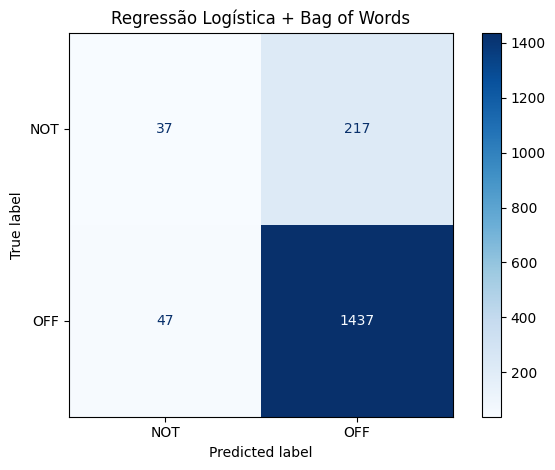

In [ ]:
# Regressão Logística com Bag of Words
rl_bow = LogisticRegression(max_iter=1000, random_state=42)
rl_bow.fit(X_train_bow, y_train)
y_pred_bow = rl_bow.predict(X_test_bow)

mostra_metricas(y_test, y_pred_bow, "Regressão Logística + Bag of Words")

 Regressão Logística + TF-IDF
Acurácia : 0.8533
F1-Score (weighted): 0.7863
F1-Score (macro)   : 0.4604

Relatório de Classificação:
              precision    recall  f1-score   support

     NOT (0)       0.00      0.00      0.00       254
     OFF (1)       0.85      1.00      0.92      1484

    accuracy                           0.85      1738
   macro avg       0.43      0.50      0.46      1738
weighted avg       0.73      0.85      0.79      1738



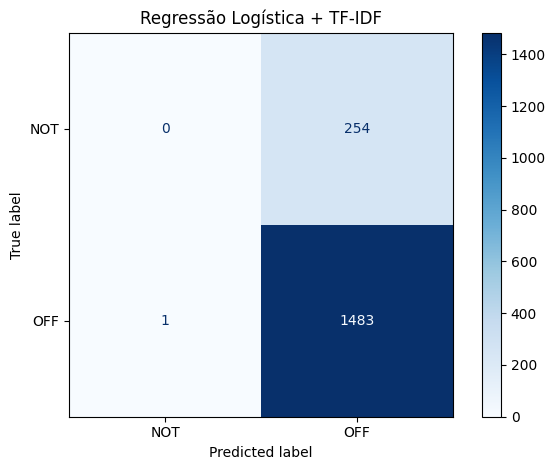

In [ ]:
# Regressão Logística com TF-IDF
rl_tfidf = LogisticRegression(max_iter=1000, random_state=42)
rl_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = rl_tfidf.predict(X_test_tfidf)

mostra_metricas(y_test, y_pred_tfidf, "Regressão Logística + TF-IDF")

## 8. Comparação dos Modelos

     Modelo  Acurácia  F1 (weighted)  F1 (macro)
   RL + BoW  0.848101       0.814016    0.567402
RL + TF-IDF  0.853280       0.786257    0.460416


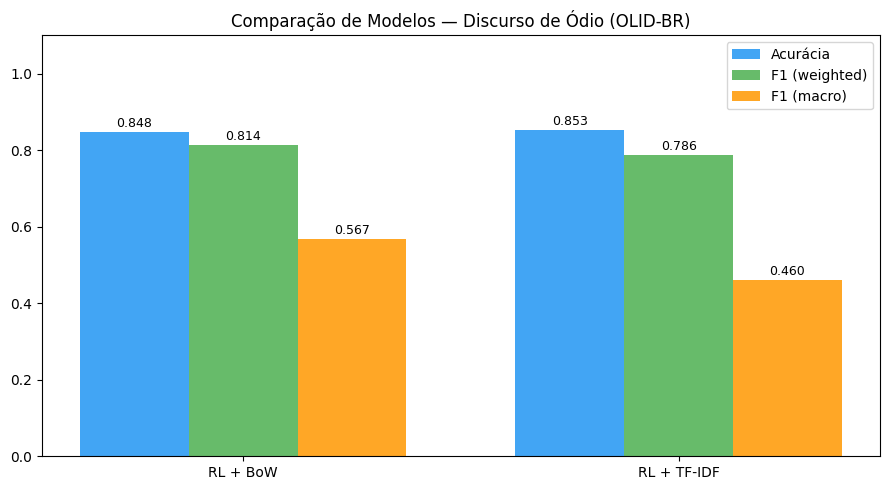

In [ ]:
resultados = pd.DataFrame({
    'Modelo': ['RL + BoW', 'RL + TF-IDF'],
    'Acurácia': [
        accuracy_score(y_test, y_pred_bow),
        accuracy_score(y_test, y_pred_tfidf)
    ],
    'F1 (weighted)': [
        f1_score(y_test, y_pred_bow, average='weighted'),
        f1_score(y_test, y_pred_tfidf, average='weighted')
    ],
    'F1 (macro)': [
        f1_score(y_test, y_pred_bow, average='macro'),
        f1_score(y_test, y_pred_tfidf, average='macro')
    ]
})

print(resultados.to_string(index=False))

# Gráfico comparativo
x = range(len(resultados))
width = 0.25
fig, ax = plt.subplots(figsize=(9, 5))

for i, (col, color) in enumerate(zip(['Acurácia', 'F1 (weighted)', 'F1 (macro)'],
                                      ['#2196F3', '#4CAF50', '#FF9800'])):
    bars = ax.bar([xi + i*width for xi in x], resultados[col], width,
                  label=col, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(resultados['Modelo'])
ax.set_ylim(0, 1.1)
ax.set_title('Comparação de Modelos — Discurso de Ódio (OLID-BR)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Palavras Mais Relevantes para Cada Classe

Vamos visualizar quais palavras o modelo TF-IDF considera mais importantes para classificar um texto como ofensivo ou não ofensivo.

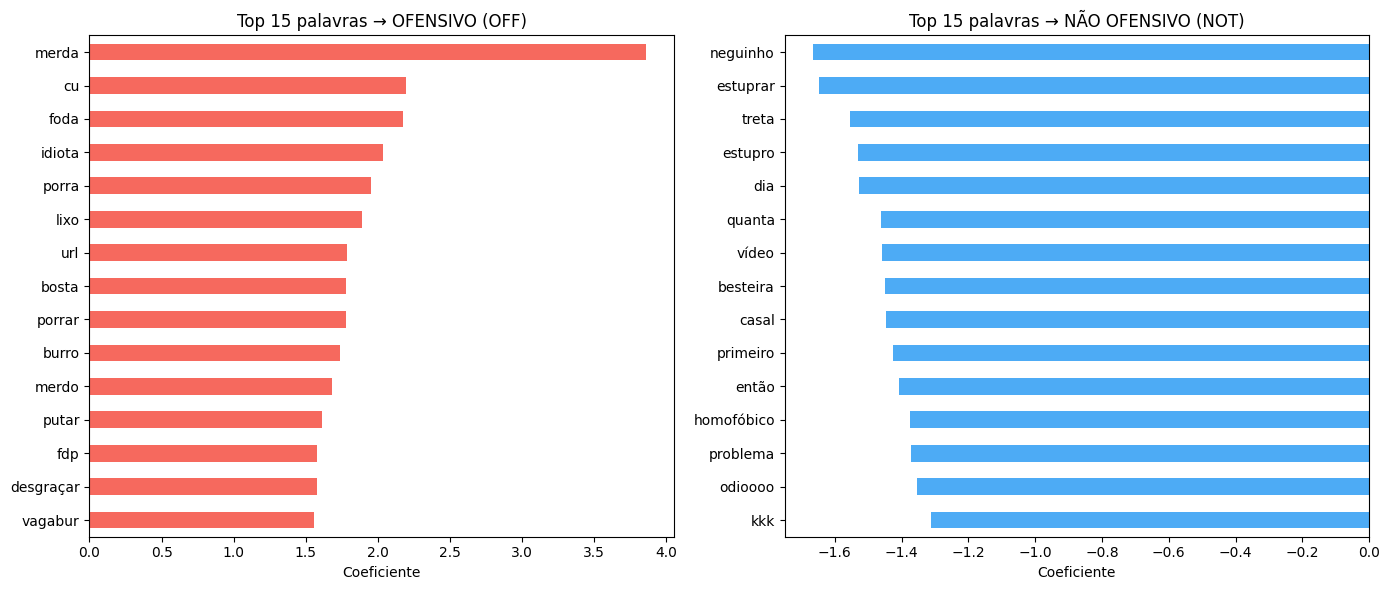

In [ ]:
feature_names = vectorizer_tfidf.get_feature_names_out()
coefs = rl_tfidf.coef_[0]

top_n = 15
top_off = pd.Series(coefs, index=feature_names).nlargest(top_n)
top_not = pd.Series(coefs, index=feature_names).nsmallest(top_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_off.sort_values().plot(kind='barh', ax=axes[0], color='#F44336', alpha=0.8)
axes[0].set_title(f'Top {top_n} palavras → OFENSIVO (OFF)', fontsize=12)
axes[0].set_xlabel('Coeficiente')

top_not.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='#2196F3', alpha=0.8)
axes[1].set_title(f'Top {top_n} palavras → NÃO OFENSIVO (NOT)', fontsize=12)
axes[1].set_xlabel('Coeficiente')

plt.tight_layout()
plt.show()

## 10. Testando com Novos Comentários

Vamos testar o modelo (melhor configuração: TF-IDF) com comentários novos, incluindo casos ambíguos para observar as limitações do modelo.

In [ ]:
def nova_predicao(texto, verbose=True):
    """Classifica um texto como ofensivo ou não ofensivo."""
    texto_clean = limpa_texto(texto)
    texto_vec = vectorizer_tfidf.transform([texto_clean])
    pred = rl_tfidf.predict(texto_vec)[0]
    proba = rl_tfidf.predict_proba(texto_vec)[0]

    if verbose:
        label = "🔴 OFENSIVO" if pred == 1 else "🟢 NÃO OFENSIVO"
        print(f"Texto   : {texto}")
        print(f"Resultado: {label}")
        print(f"Confiança: NOT={proba[0]:.2%} | OFF={proba[1]:.2%}")
        print()
    return pred

In [ ]:
# Casos relativamente claros
print("=== Casos mais claros ===")
nova_predicao("Que governo incompetente, não fazem nada direito!")
nova_predicao("Parabéns pelo trabalho, ficou excelente!")
nova_predicao("Discordo totalmente da sua opinião sobre isso.")

=== Casos mais claros ===
Texto   : Que governo incompetente, não fazem nada direito!
Resultado: 🔴 OFENSIVO
Confiança: NOT=17.88% | OFF=82.12%

Texto   : Parabéns pelo trabalho, ficou excelente!
Resultado: 🔴 OFENSIVO
Confiança: NOT=20.69% | OFF=79.31%

Texto   : Discordo totalmente da sua opinião sobre isso.
Resultado: 🔴 OFENSIVO
Confiança: NOT=17.60% | OFF=82.40%



np.int64(1)

In [ ]:
# Casos ambíguos — onde o modelo pode errar
print("=== Casos ambíguos (onde modelos simples costumam falhar) ===")
nova_predicao("Esse povo não tem jeito mesmo, só sabe reclamar")
nova_predicao("Nossa, que inteligência a desse aqui hein...")
nova_predicao("Típico né, sempre assim com essa turma")

=== Casos ambíguos (onde modelos simples costumam falhar) ===
Texto   : Esse povo não tem jeito mesmo, só sabe reclamar
Resultado: 🔴 OFENSIVO
Confiança: NOT=19.78% | OFF=80.22%

Texto   : Nossa, que inteligência a desse aqui hein...
Resultado: 🔴 OFENSIVO
Confiança: NOT=16.33% | OFF=83.67%

Texto   : Típico né, sempre assim com essa turma
Resultado: 🔴 OFENSIVO
Confiança: NOT=12.99% | OFF=87.01%



np.int64(1)

In [ ]:
# Teste interativo — experimente você mesmo!
comentario = input("Digite um comentário para classificar: ")
nova_predicao(comentario)

Digite um comentário para classificar: você é incrivel
Texto   : você é incrivel
Resultado: 🔴 OFENSIVO
Confiança: NOT=16.08% | OFF=83.92%



np.int64(1)

## 11. Reflexão: Limitações do Modelo

Os modelos clássicos de NLP (BoW + TF-IDF + Regressão Logística) têm **limitações importantes** para esta tarefa:

| Limitação | Descrição |
|-----------|----------|
| **Sem contexto** | Tratam cada palavra independentemente; não entendem ironia ou sarcasmo |
| **Gírias e dog-whistles** | Linguagem codificada não aparece no vocabulário de treino |
| **Negações** | "não é racismo" pode ser classificado errado pela presença da palavra |
| **Grupo alvo** | Não identificam *contra quem* o discurso é direcionado |
| **Classe minoritária** | Desbalanceamento faz o modelo priorizar a classe majoritária |

### Próximos Passos Possíveis

- Usar **modelos de linguagem pré-treinados** como BERTimbau ou mDeBERTa
- Aplicar técnicas de **balanceamento de classes** (SMOTE, class_weight)
- Incorporar **n-gramas** no TF-IDF para capturar expressões compostas
- Usar **LinearSVC** como baseline mais robusto que Regressão Logística